### About Plotly

Plotly is a Data Viz library by the company Plotly based out of Canada with support in languages such as Python, Js, Julia etc.

#### Advantages

- Multi language support
- Lot's of graphs
- Interactive plots
- Beautiful plots

Does not work with live data streams. Dash can be explored for that.

### The Plotly Roadmap

- Plotly Go
- Plotly Express
- Dash

### Working with Plotly Go

In [39]:
# import the libraries
import plotly.graph_objects as go
import numpy as np
import pandas as pd
import plotly.express as px

In [40]:
!pip install plotly

In [41]:
# import datasets
tips = px.data.tips()
iris = px.data.iris()
gap = px.data.gapminder()

In [42]:
gap.head()

,country,continent,year,lifeExp,pop,gdpPercap,iso_alpha,iso_num
0,Afghanistan,Asia,1952,28.801,8425333,779.445314,AFG,4
1,Afghanistan,Asia,1957,30.332,9240934,820.853030,AFG,4
2,Afghanistan,Asia,1962,31.997,10267083,853.100710,AFG,4
3,Afghanistan,Asia,1967,34.020,11537966,836.197138,AFG,4
4,Afghanistan,Asia,1972,36.088,13079460,739.981106,AFG,4


In [43]:
# scatter plot using plotly go

temp_df = gap[gap['year'] == 2007]
temp_df

,country,continent,year,lifeExp,pop,gdpPercap,iso_alpha,iso_num
11,Afghanistan,Asia,2007,43.828,31889923,974.580338,AFG,4
23,Albania,Europe,2007,76.423,3600523,5937.029526,ALB,8
35,Algeria,Africa,2007,72.301,33333216,6223.367465,DZA,12
47,Angola,Africa,2007,42.731,12420476,4797.231267,AGO,24
59,Argentina,Americas,2007,75.320,40301927,12779.379640,ARG,32
...,...,...,...,...,...,...,...,...
1655,Vietnam,Asia,2007,74.249,85262356,2441.576404,VNM,704
1667,West Bank and Gaza,Asia,2007,73.422,4018332,3025.349798,PSE,275
1679,"Yemen, Rep.",Asia,2007,62.698,22211743,2280.769906,YEM,887
1691,Zambia,Africa,2007,42.384,11746035,1271.211593,ZMB,894


In [44]:

trace1 = go.Scatter(x=temp_df['lifeExp'],y=temp_df['gdpPercap'],mode='markers')
trace2 = go.Scatter(x=[0,1,2],y=[0,90,30000],mode='lines')

data = [trace1,trace2]

layout = go.Layout(title='Life Exp Vs GDP per Capita for 2007', xaxis={'title':'Life Exp'},yaxis={'title':'GDP'})
fig = go.Figure(data,layout)

fig.show()

In [45]:
# plot life exp and gdp scatter plot -> continent as color -> pop as size -> hover name -> range_x/range_y -> log_x/log_y
px.scatter(temp_df, x='lifeExp', y='gdpPercap',color='continent',size='pop',size_max=100, hover_name='country')

In [46]:
# plot animation of the above curve on the basic of year
px.scatter(gap, x='lifeExp', y='gdpPercap',
           color='continent',size='pop',
           size_max=100, hover_name='country',
           range_x=[30,95],
           animation_frame='year',animation_group='country')

In [47]:
# line plot
# plot india pop line plot
temp_df = gap[gap['country'] == 'India']

px.line(temp_df, x='year', y='pop',title='India pop growth')

In [48]:
# plot india china pak line plot
temp_df = gap[gap['country'].isin(['India','China','Pakistan'])].pivot(index='year',columns='country',values='lifeExp')
temp_df

country,China,India,Pakistan
year,,,
1952,44.00000,37.373,43.436
1957,50.54896,40.249,45.557
1962,44.50136,43.605,47.670
1967,58.38112,47.193,49.800
1972,63.11888,50.651,51.929
1977,63.96736,54.208,54.043
1982,65.52500,56.596,56.158
1987,67.27400,58.553,58.245
1992,68.69000,60.223,60.838


In [49]:
px.line(temp_df, x=temp_df.index, y=temp_df.columns)

In [50]:
# bar chart
# india's pop over the years
temp_df = gap[gap['country'] == 'India']
px.bar(temp_df,x='year',y='pop')

In [51]:
# pop comp of 3 countries
temp_df = gap[gap['country'].isin(['India','China','Pakistan'])].pivot(index='year',columns='country',values='pop')
temp_df

country,China,India,Pakistan
year,,,
1952,556263527,372000000,41346560
1957,637408000,409000000,46679944
1962,665770000,454000000,53100671
1967,754550000,506000000,60641899
1972,862030000,567000000,69325921
1977,943455000,634000000,78152686
1982,1000281000,708000000,91462088
1987,1084035000,788000000,105186881
1992,1164970000,872000000,120065004


In [52]:
# grouped bar chart -> text_auto
px.bar(temp_df,x=temp_df.index,y=temp_df.columns,barmode='group',log_y=True,text_auto=True)

In [53]:
# stacked bar chart
# pop contribution per country to a continents pop stacked for a particular year(2007)
temp_df = gap[gap['year'] == 2007]
px.bar(temp_df, x='continent', y='pop', color='country',log_y=True)

In [54]:
# bar chart animation
px.bar(gap, x='continent',y='pop',color='continent',animation_frame='year',animation_group='country',range_y=[0,4000000000])

In [55]:
# histogram
# plot histogram of life expt of all countries in 2007 -> nbins -> text_auto
temp_df = gap[gap['year'] == 2007]

px.histogram(temp_df, x='lifeExp',nbins=10,text_auto=True)

In [56]:
# plot histogram of sepal length of all iris species
px.histogram(iris,x='sepal_length',color='species',nbins=30,text_auto=True)

In [57]:
# Pie -> values -> names
# find the pie chart of pop of european countries in 2007

temp_df = gap[(gap['year'] == 2007) & (gap['continent'] == 'Europe')]

px.pie(temp_df, values='pop', names='country')

In [58]:
# plot pie chart of world pop in 1952 continent wise ->  -> explode(pull)

temp_df = gap[gap['year'] == 1952].groupby('continent')['pop'].sum().reset_index()
px.pie(temp_df, values='pop', names='continent')

In [59]:
# Sunburst plot -> Sunburst plots visualize hierarchical data spanning outwards radially from root to leaves. -> color
# path -> [], values

temp_df = gap[gap['year'] == 2007]

px.sunburst(temp_df, path=['continent','country'],values='pop',color='lifeExp')

In [60]:
px.sunburst(tips,path=['sex','smoker','day','time'],values='total_bill',color='size')

In [61]:
# Treemap
temp_df = gap[gap['year'] == 2007]

px.treemap(temp_df, path=[px.Constant('World'),'continent','country'],values='pop',color='lifeExp')

In [62]:
# Heatmap -> find heatmap of all continents with year on avg life exp
#temp_df = tips.pivot_table(index='day',columns='sex',values='total_bill',aggfunc='sum')

temp_df = gap.pivot_table(index='year',columns='continent',values='lifeExp',aggfunc='mean')
px.imshow(temp_df)

In [63]:
# 3d scatterplot
# plot a 3d scatter plot of all country data for 2007
temp_df = gap[gap['year'] == 2007]
px.scatter_3d(temp_df, x='lifeExp',y='pop',z='gdpPercap',log_y=True,color='continent',hover_name='country')

In [64]:
px.scatter_3d(iris,x='sepal_length',y='sepal_width',z='petal_length',color='species')

In [65]:
# scatter_matrix -> dimensions
px.scatter_matrix(iris,dimensions=['sepal_length','sepal_width','petal_length','petal_width'],color='species')

In [66]:
import plotly.graph_objects as go
import plotly.express as px
import numpy as np

In [67]:
# facet plot
tips = px.data.tips()
gap = px.data.gapminder()

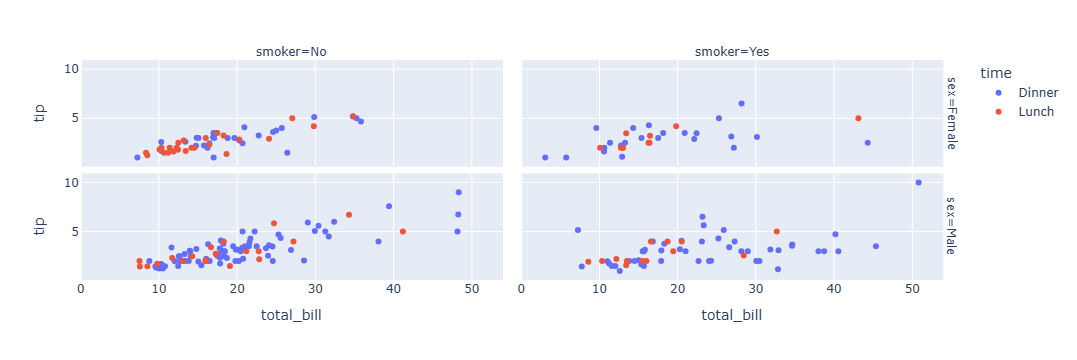

In [68]:
px.scatter(tips, x='total_bill', y='tip', facet_col='smoker', facet_row='sex',color='time')

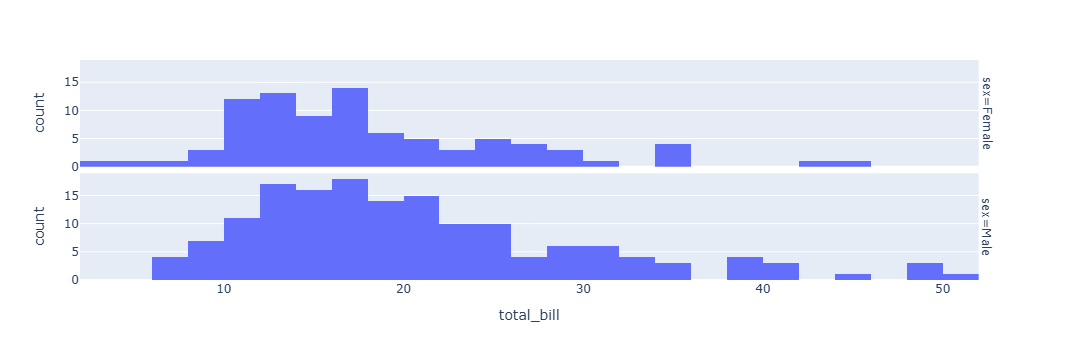

In [69]:
px.histogram(tips,x='total_bill',facet_row='sex')

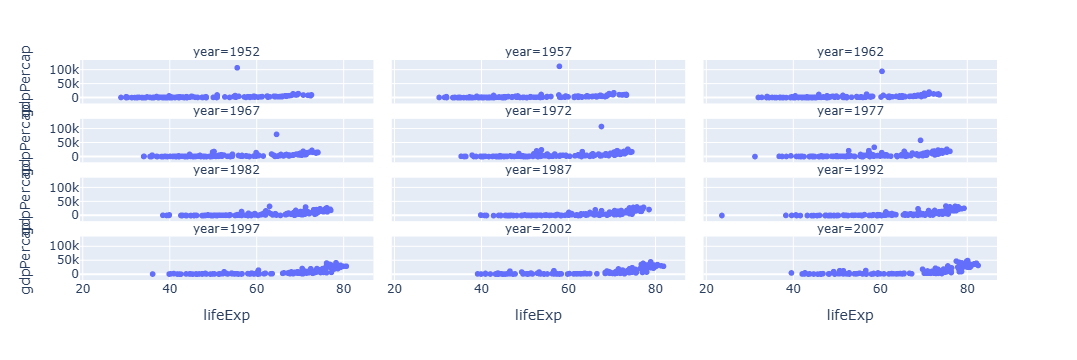

In [70]:
px.scatter(gap, x='lifeExp', y='gdpPercap', facet_col='year', facet_col_wrap=3)

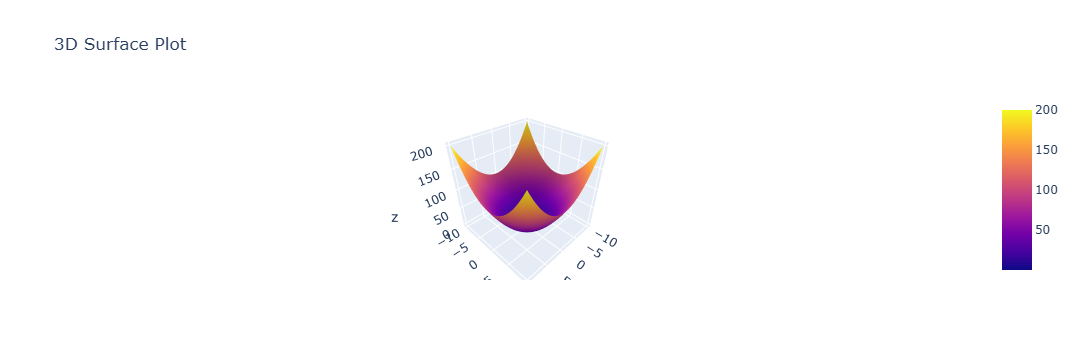

In [71]:
# 3d Surface plot
# can not be created using Plotly express
# we will use plotly graph object -> go

x = np.linspace(-10,10,100)
y = np.linspace(-10,10,100)

xx, yy = np.meshgrid(x,y)

z = xx**2 + yy**2
# z = np.sin(xx) + np.tan(yy)
# z = np.sqrt(xx**2 + yy**2)


trace = go.Surface(x=x,y=y,z=z)

data = [trace]

layout = go.Layout(title='3D Surface Plot')

fig = go.Figure(data,layout)

fig.show()

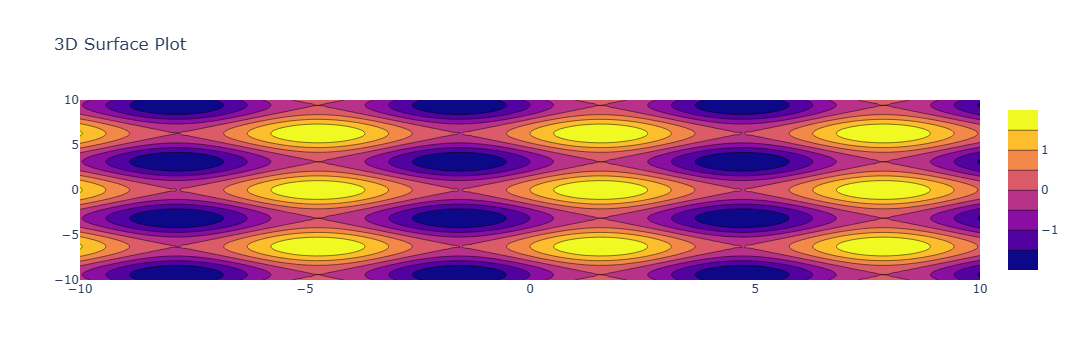

In [72]:
# Contour plot
x = np.linspace(-10,10,100)
y = np.linspace(-10,10,100)

xx, yy = np.meshgrid(x,y)

# z = xx**2 + yy**2
z = np.sin(xx) + np.cos(yy)
# z = np.sqrt(xx**2 + yy**2)


trace = go.Contour(x=x,y=y,z=z)

data = [trace]

layout = go.Layout(title='3D Surface Plot')

fig = go.Figure(data,layout)

fig.show()

In [73]:
# Subplots
from plotly.subplots import make_subplots

In [74]:
fig = make_subplots(rows=2,cols=2)

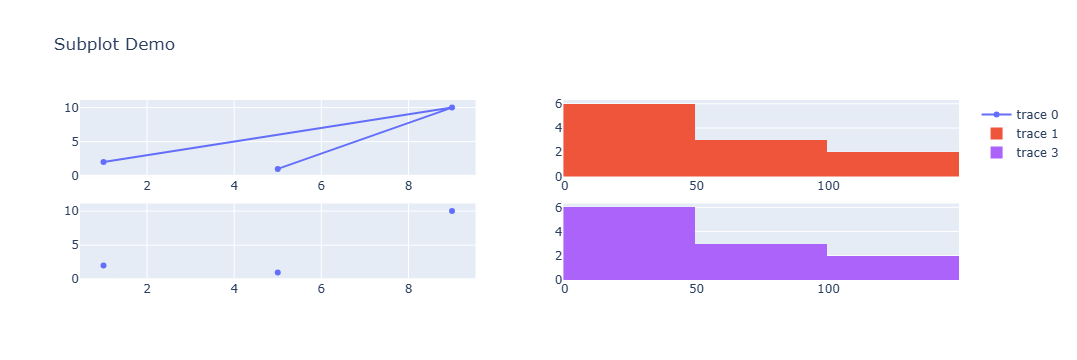

In [76]:
from plotly.subplots import make_subplots
import plotly.graph_objects as go
import plotly.express as px

fig = make_subplots(rows=2, cols=2)

# 1st plot
fig.add_trace(
    go.Scatter(x=[1,9,5], y=[2,10,1]),
    row=1,
    col=1
)

# 2nd plot
fig.add_trace(
    go.Histogram(x=[1,9,5,22,109,134,56,78,12,34,89]),
    row=1,
    col=2
)

# px.scatter -> convert to trace
scatter_fig = px.scatter(x=[1,9,5], y=[2,10,1])

fig.add_trace(
    scatter_fig.data[0],   # extract trace
    row=2,
    col=1
)

# 4th plot
fig.add_trace(
    go.Histogram(x=[1,9,5,22,109,134,56,78,12,34,89]),
    row=2,
    col=2
)

fig.update_layout(title='Subplot Demo')

fig.show()